In [24]:
# taken from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

#%matplotlib inline
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data
from torch.utils.data import Dataset, DataLoader
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.transforms.v2 as v2transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from PIL import Image
import skimage
from skimage import io, transform

# Definitions

In [25]:
batch_size = 96
image_size = 324
workers = 2
rootdir = "/Users/ishwar/Desktop/"

In [26]:
class Prnt(nn.Module):
    def __init__(self):
        super(Prnt, self).__init__()

    def forward(self, x):
        print(x)
        return x
    
NUM_LANDMARKS = 5

class ImgToHeatmap(nn.Module):
    def __init__(self):
        super(ImgToHeatmap, self).__init__()
        
        self.modules = []

        self.kernelSize = 5 # must be odd

        self.internal = 15
        self.layers = 4

        self.num_landmarks = NUM_LANDMARKS

        self.p_dropout = 0.8

        # cumulatively, take 4-dim vector and output 4-dim vector
        # first two dims: actual vector
        # second two dims: state vector

        self.modules.append(nn.Conv2d(3, self.internal, self.kernelSize, stride=1, \
                                      padding=(self.kernelSize-1)//2))
        for i in range(self.layers):
            self.modules.append(nn.Conv2d(self.internal, self.internal, self.kernelSize, stride=1, \
                                      padding=(self.kernelSize-1)//2))
            self.modules.append(nn.ReLU())
            self.modules.append(nn.Dropout(p=self.p_dropout))
            
        self.modules.append(nn.Conv2d(self.internal, self.num_landmarks, self.kernelSize, stride=1, \
                                      padding=(self.kernelSize-1)//2))
        
        self.main = nn.Sequential(*self.modules)

    def forward(self, input):
        z = self.main(input)
        return z


In [27]:
weight_spread = 0.05
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Linear') != -1:
        #nn.init.normal_(m.weight.data, 0.0, 1/16) # not tried yet
        nn.init.normal_(m.weight.data, 0.0, weight_spread)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, weight_spread)
        nn.init.normal_(m.bias.data, 0.0, weight_spread)
    m = m.to(torch.float32)

clip_value =  5
class WeightConstraint(object):
    def __init__(self):
        pass
    def __call__(self, module):
        # filter the variables to get the ones you want
        if hasattr(module, 'weight'):
            w = module.weight.data
            w = w.clamp(-clip_value, clip_value)
            module.weight.data = w

In [28]:
# Set random seed for reproducibility
manualSeed = 499
#manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)

torch.use_deterministic_algorithms(True) # Needed for reproducible resultsStop playing

Random Seed:  499


In [53]:
def coord_to_heatmap(coord_array, image_shape, device):
    heatmaps = torch.zeros((NUM_LANDMARKS, image_shape[1], image_shape[2]))
    for i in range(NUM_LANDMARKS):
        mu_x, mu_y = coord_array[i][0], coord_array[i][1]   # center (x,y)
        sigma = 5.00

        ys = torch.arange(image_shape[1], device=device, dtype=torch.float32)
        xs = torch.arange(image_shape[2], device=device, dtype=torch.float32)
        yy, xx = torch.meshgrid(ys, xs, indexing='ij')          # HxW each

        img = torch.exp(-0.5 * ((xx - mu_x)**2 + (yy - mu_y)**2) / (sigma**2))
        # (optional) normalize to peak 1
        img = img / torch.sum(img)
        heatmaps[i] = img
    return heatmaps

In [54]:
class FramesFromCSV(Dataset):
    def __init__(self, csv_path, images_dir, image_pattern="frame_{frame}.png", transform=None):
        """
        Args:
            csv_path: path to CSV file with header in first row
            images_dir: directory containing frame PNGs
            image_pattern: naming pattern for image files
            transform: optional torchvision transform
        """
        self.images_dir = images_dir
        self.image_pattern = image_pattern
        self.transform = transform

        # Load CSV into numpy array, skipping header
        self.data = np.loadtxt(csv_path, delimiter=",", skiprows=1)
        # Ensure it's 2D even if only one row
        if self.data.ndim == 1:
            self.data = np.expand_dims(self.data, axis=0)

        self.frame_numbers = self.data[:, 0].astype(int)
        self.points = self.data[:, 1:]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        frame_num = self.frame_numbers[idx]
        coords = self.points[idx]

        # Load image
        img_path = os.path.join(self.images_dir, self.image_pattern.format(frame=frame_num))
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Reshape coords into N×2 array (x, y)
        coords = coords.reshape(-1, 2)
        coords_tensor = torch.tensor(coords, dtype=torch.float32)

        return {
            "image": image,
            "points": coords_tensor,
            "heatmaps": coord_to_heatmap(coords_tensor, image.shape, "cpu"),
            "frame": frame_num
        }


In [55]:
dataset = FramesFromCSV(
    csv_path="labeled_points_mega_grp.csv",
    images_dir="outp",
    image_pattern="frame_{frame}.png",
    transform=transforms.ToTensor()
)

In [56]:
print(dataset[11])

{'image': tensor([[[0.2471, 0.2471, 0.2471,  ..., 0.2549, 0.2549, 0.2549],
         [0.2471, 0.2471, 0.2471,  ..., 0.2549, 0.2549, 0.2549],
         [0.2471, 0.2471, 0.2471,  ..., 0.2549, 0.2549, 0.2549],
         ...,
         [0.2824, 0.2824, 0.2824,  ..., 0.2980, 0.2980, 0.2980],
         [0.2824, 0.2824, 0.2824,  ..., 0.2980, 0.2980, 0.2980],
         [0.2824, 0.2824, 0.2824,  ..., 0.2980, 0.2980, 0.2980]],

        [[0.3765, 0.3765, 0.3765,  ..., 0.3765, 0.3804, 0.3804],
         [0.3765, 0.3765, 0.3765,  ..., 0.3765, 0.3804, 0.3804],
         [0.3765, 0.3765, 0.3765,  ..., 0.3686, 0.3765, 0.3765],
         ...,
         [0.4039, 0.4039, 0.4039,  ..., 0.4235, 0.4235, 0.4235],
         [0.4039, 0.4039, 0.4039,  ..., 0.4235, 0.4235, 0.4235],
         [0.4039, 0.4039, 0.4039,  ..., 0.4235, 0.4235, 0.4235]],

        [[0.5373, 0.5373, 0.5373,  ..., 0.5490, 0.5255, 0.5255],
         [0.5373, 0.5373, 0.5373,  ..., 0.5490, 0.5255, 0.5255],
         [0.5373, 0.5373, 0.5373,  ..., 0.6157, 

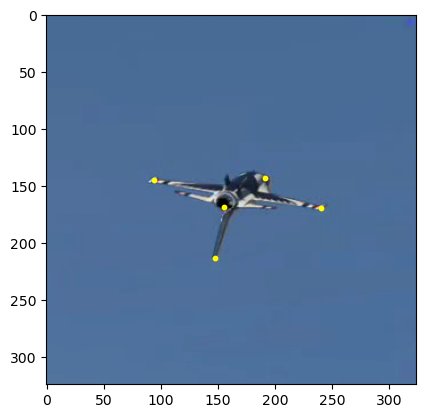

In [87]:
IMG_IDX = 330
plt.imshow(torch.permute(dataset[IMG_IDX]['image'], (1, 2, 0)))
# Unpack points into two lists: xs, ys
xs = [p[0] for p in dataset[IMG_IDX]['points']]
ys = [p[1] for p in dataset[IMG_IDX]['points']]
# Plot points as red circles
plt.scatter(xs, ys, c='yellow', s=10)  # s = point size

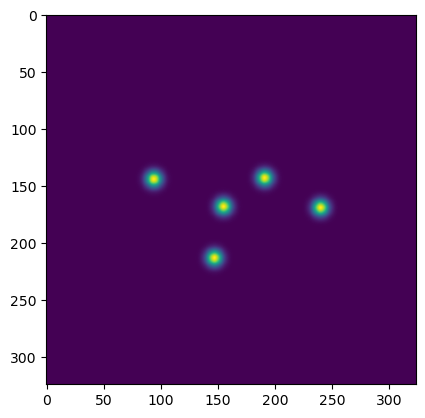

In [88]:
plt.imshow(torch.sum(dataset[IMG_IDX]['heatmaps'], axis=0))

In [ ]:
loader = DataLoader(dataset, batch_size=4, shuffle=False)

for batch in loader:
    print(batch["frame"])
    print(batch["points"].shape)  # (B, N, 2)
    break

torch.Size([3, 128, 128])


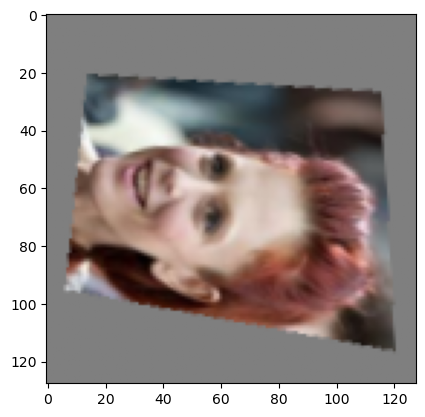

In [70]:
print(aug_dset[11][0].shape)
plt.imshow((torch.permute(aug_dset[11][0], (1, 2, 0)) + 1) / 2)

In [71]:
trial_number = 0

from datetime import datetime
import time

# instantiate generator, discriminator
# borrowed from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

# if not os.path.exists(datapath+"/trial_"+str(trial_number)):
#     os.mkdir(datapath+"/trial_"+str(trial_number))

device = torch.device("cuda:0" if (torch.cuda.is_available()) else "cpu")
print("device: ", device)

print("Instantiating Encoder / Decoder")
# Create the generator
enc = Encoder().to(device, dtype=torch.float32)
enc.apply(weights_init)
print(enc)
dec = Decoder().to(device, dtype=torch.float32)
dec.apply(weights_init)
print(dec)

# Setup Adam optimizers for both G and D
optimizerE = optim.Adam(enc.parameters(), lr=0.0005, betas=(0.5, 0.999))
optimizerD = optim.Adam(dec.parameters(), lr=0.0005, betas=(0.5, 0.999))
print("Encoder optimizer: \n", optimizerE)
print("Decoder optimizer: \n", optimizerD)

criterion = nn.MSELoss()

clipper = WeightConstraint()

device:  cpu
Instantiating Encoder / Decoder
Encoder(
  (main): Sequential(
    (0): Conv2d(3, 15, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Conv2d(15, 15, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (2): ReLU()
    (3): Dropout(p=0.8, inplace=False)
    (4): Conv2d(15, 15, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): ReLU()
    (6): Dropout(p=0.8, inplace=False)
    (7): Conv2d(15, 15, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (8): ReLU()
    (9): Dropout(p=0.8, inplace=False)
    (10): Conv2d(15, 15, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (11): ReLU()
    (12): Dropout(p=0.8, inplace=False)
    (13): Conv2d(15, 5, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
)
Decoder(
  (main): Sequential(
    (0): Conv2d(5, 20, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Conv2d(20, 20, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (2): ReLU()
    (3): Dropout(p=0.8, inplace=False)
    (4): Co

In [72]:

iters = 0
epoch = 0
num_epochs = 500
#k=500 # saving images of fixed_noise outputs
last_save = iters
break_flag = False

losses = []

In [ ]:
iters = 0
epoch = 0
num_epochs = 500
#k=500 # saving images of fixed_noise outputs
last_save = iters
break_flag = False

In [73]:
# train the model
# borrowed from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

#train_D_only = False
#train_G_only = False
print("Starting Training Loop...")
while (epoch < num_epochs) and (not break_flag):
    # For each batch in the dataloader
    should_break = False
    
    for i, data in enumerate(dataloader, 0):
        print("Epoch\t"+str(epoch)+", batch\t"+str(i)+".", end="\n")
         # Check how the generator is doing by saving G's output on fixed_noise
        #if (epoch % k == 0) and (i == len(dataloader)-1):
        data_input = data[0]

        data_input = data_input.to(device, dtype=torch.float32)
        batch_size = data_input.size(0)
        print("Batch size: ", batch_size)
        print(data_input.dtype)

        # print(dataseq.shape)

        latent_hard_grad, latent_logits, latent_logits_softmax = enc(data_input) # outputs logits
        output = dec(latent_hard_grad)

        enc.zero_grad()
        dec.zero_grad()

        err = criterion(output, data_input)
        err_tv = total_variation_loss(latent_logits)
        #err_det = determinism_loss(logits=latent_logits)
        err_det = determinism_loss(p=latent_logits_softmax, kind="entropy")

        # use this error only when latent space categories are diverse enough

        latent_diversity = torch.mean(latent_hard_grad.to(dtype=torch.float32), dim=(0, 2, 3))

        print(f"\tRepresentation of latent categories: {latent_diversity}")

        # # find the frequency of the least represented category; 
        # if torch.min(latent_diversity) > 1 / (2 * latent_diversity.shape[0]):
        #     err_total = err + err_tv*0.1
        # else:
        #     err_total = err

        y_err = 1
        #y_err_tv = 1
        y_err_tv = 0
        y_err_det = 0

        err_total = err*y_err + err_tv*y_err_tv + err_det*y_err_det
        
        err_total.backward()

        optimizerE.step()
        optimizerD.step()
        # rnn.apply(clipper)

        #time.sleep(1.00)

        print(f"\tMean loss (per pixel): {err.item()}*{y_err} + {err_tv.item()}*{y_err_tv} + {err_det.item()}*{y_err_det} = {err_total.item()}")
        losses.append((epoch, i, iters, {"mse_error": err.item(), "total_var": err_tv.item(), "determinism:": err_det.item()},
                                        {"y_mse_error": y_err, "y_total_var": y_err_tv, "y_determinism:": y_err_det} ))

        iters += 1
    
        if iters > 1000: # stop to quickly see results
            should_break = True
            break
    
    if should_break:
        break

    epoch += 1

Starting Training Loop...
Epoch	0, batch	0.
Batch size:  96
torch.float32
	Representation of latent categories: tensor([0.2129, 0.1882, 0.2053, 0.1867, 0.2069], grad_fn=<MeanBackward1>)
	Mean loss (per pixel): 0.2090873122215271*1 + 0.17951060831546783*0 + 0.32123714685440063*0 = 0.2090873122215271
Epoch	0, batch	1.
Batch size:  96
torch.float32
	Representation of latent categories: tensor([0.2425, 0.2006, 0.1963, 0.1738, 0.1869], grad_fn=<MeanBackward1>)
	Mean loss (per pixel): 0.20191951096057892*1 + 0.215226948261261*0 + 0.3209390342235565*0 = 0.20191951096057892
Epoch	0, batch	2.
Batch size:  96
torch.float32
	Representation of latent categories: tensor([0.2679, 0.2126, 0.1884, 0.1600, 0.1711], grad_fn=<MeanBackward1>)
	Mean loss (per pixel): 0.18106357753276825*1 + 0.26591622829437256*0 + 0.3203558027744293*0 = 0.18106357753276825
Epoch	0, batch	3.
Batch size:  96
torch.float32
	Representation of latent categories: tensor([0.2944, 0.2266, 0.1817, 0.1539, 0.1434], grad_fn=<MeanBack

KeyboardInterrupt: 

In [74]:
enc.eval()
dec.eval()

Decoder(
  (main): Sequential(
    (0): Conv2d(5, 20, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Conv2d(20, 20, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (2): ReLU()
    (3): Dropout(p=0.8, inplace=False)
    (4): Conv2d(20, 20, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): ReLU()
    (6): Dropout(p=0.8, inplace=False)
    (7): Conv2d(20, 20, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (8): ReLU()
    (9): Dropout(p=0.8, inplace=False)
    (10): Conv2d(20, 20, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (11): ReLU()
    (12): Dropout(p=0.8, inplace=False)
    (13): Conv2d(20, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
)

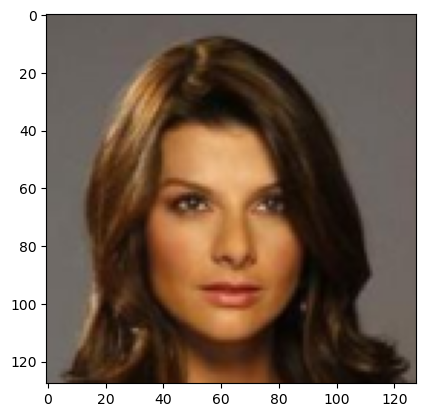

In [75]:
example_point = aug_dset[330][0]
image = torch.permute(example_point, (1, 2, 0))
plt.imshow((image.numpy()/2)+0.5)

torch.Size([1, 128, 128, 5])
Logit softmax min and max: 3.834625488252641e-07 to 0.9945883750915527


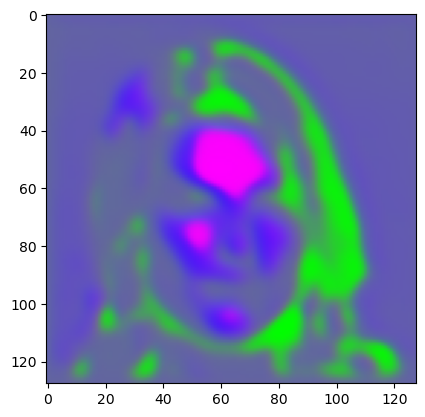

In [82]:
colormap_matrix = torch.Tensor([[255, 0, 0, 255, 0],\
                               [0, 255, 0, 0, 255],\
                               [0, 0, 255, 255, 255]])

input_example = example_point.to(dtype=torch.float32)
latent_example, _, latent_logits_softmax = enc(torch.stack((input_example,)))
latent_example = latent_example.detach()
latent_logits_softmax = latent_logits_softmax.detach()
latent_tr = torch.permute(latent_logits_softmax, (0, 2, 3, 1))
print(latent_tr.shape)
#print(latent_tr)
print(f"Logit softmax min and max: {torch.min(latent_tr)} to {torch.max(latent_tr)}")
latent_img = torch.matmul(latent_tr, colormap_matrix.T).to(torch.int)
latent_img = (latent_img - torch.min(latent_img)) / (torch.max(latent_img) - torch.min(latent_img))
plt.imshow(latent_img.numpy()[0])

torch.Size([1, 128, 128])


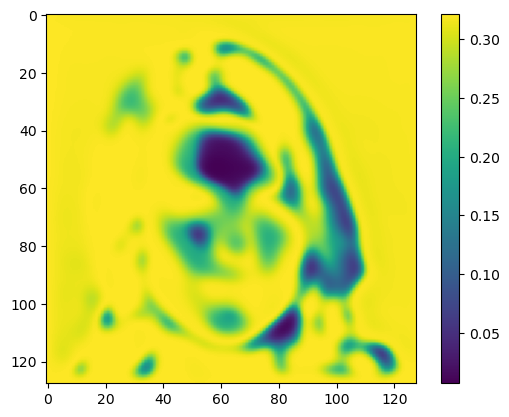

In [83]:
latent_logits_softmax_entropy = torch.mean(-latent_logits_softmax * torch.log(latent_logits_softmax), axis=1)
latent_tr = latent_logits_softmax_entropy
print(latent_tr.shape)
#print(latent_tr)
latent_img = latent_tr
plt.imshow(latent_img.numpy()[0])
plt.colorbar()

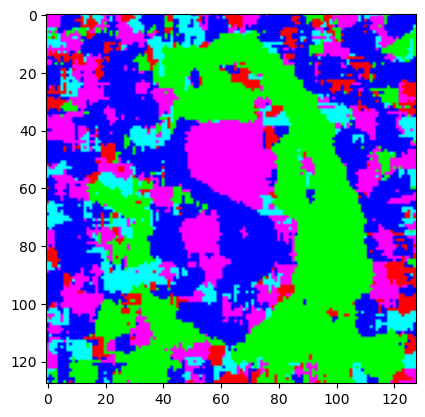

In [84]:
latent_tr = torch.permute(latent_example, (0, 2, 3, 1))
#print(latent_tr.shape)
#print(latent_tr)
latent_img = torch.matmul(latent_tr, colormap_matrix.T).to(torch.int)
plt.imshow(latent_img.numpy()[0])

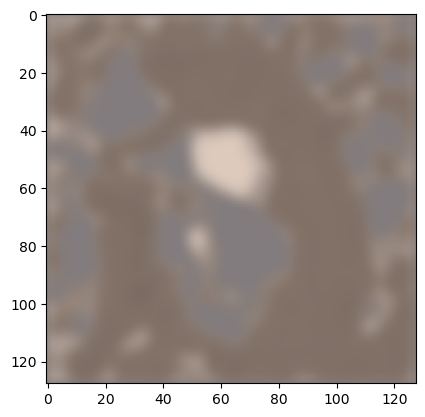

In [85]:
output_example = dec(latent_example).detach()
output_tr = torch.permute(output_example, (0, 2, 3, 1))
plt.imshow((output_tr.numpy()[0]/2)+0.5)

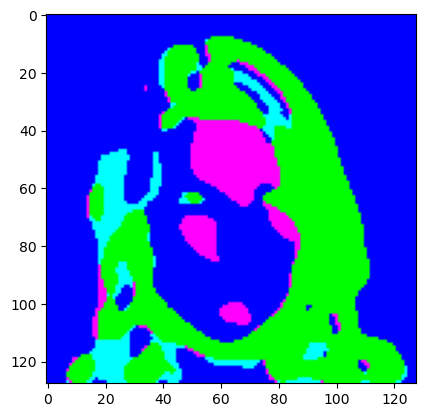

In [80]:
# Step 1: Get the predicted class index for each sample
# torch.argmax returns the index of the maximum value along the specified dimension.
# dim=-1 indicates the last dimension (which represents the classes).
predicted_classes = torch.argmax(torch.permute(latent_logits_softmax, (0, 2, 3, 1)), dim=-1).detach()

# Step 2: Convert the class indices to one-hot vectors
# num_classes should be the total number of possible classes.
num_classes = latent_logits.shape[-3]
z_hard = torch.permute(F.one_hot(predicted_classes, num_classes=num_classes), (0, 3, 1, 2)).to(dtype=torch.float32)

latent_tr = torch.permute(z_hard, (0, 2, 3, 1)).to(dtype=torch.float32)
latent_img = torch.matmul(latent_tr, colormap_matrix.T).to(torch.int)
plt.imshow(latent_img.numpy()[0])

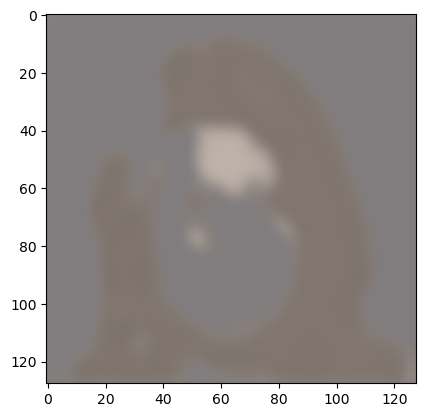

In [81]:
output_example = dec(z_hard).detach()
output_tr = torch.permute(output_example, (0, 2, 3, 1))
plt.imshow((output_tr.numpy()[0]/3)+0.5)

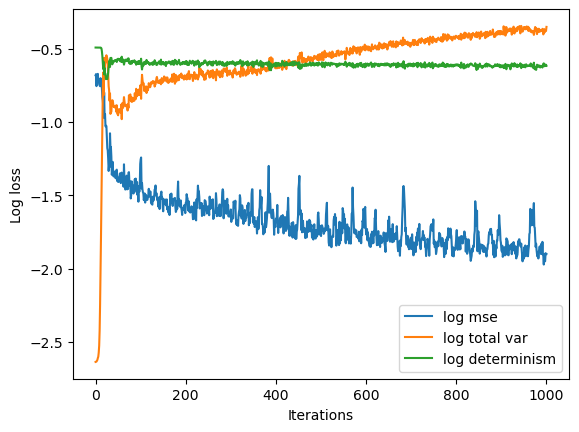

<Figure size 1920x1440 with 0 Axes>

In [143]:
import math
# {"mse_error": err.item(), "total_var": err_tv.item(), "determinism:": err_det.item()},
plt.plot([x[2] for x in losses], [math.log(x[3]["mse_error"])/math.log(10) for x in losses], label="log mse")
plt.plot([x[2] for x in losses], [math.log(x[3]["total_var"])/math.log(10) for x in losses], label="log total var")
plt.plot([x[2] for x in losses], [math.log(x[3]["determinism:"])/math.log(10) for x in losses], label="log determinism")
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Log loss")
plt.figure(dpi=300) # Set DPI to 300 for this figure
plt.show()

# Read in data

In [2]:
datapath = "/Users/ishwar/Desktop/Music_DL/other/onehotzig_randstart_dataset/"
filelist_fname = "onehotzig_dataset_files.txt"

filelist = []

f = open(datapath+filelist_fname, "r")
fnames = f.readlines()
f.close()
for i in range(0, len(fnames)):
    fn = fnames[i]
    fn = fn.strip('\n')
    print(i, fn)
    filelist.append(fn)

print(len(filelist))

0 sample_0.pt
1 sample_1.pt
2 sample_2.pt
3 sample_3.pt
4 sample_4.pt
5 sample_5.pt
6 sample_6.pt
7 sample_7.pt
8 sample_8.pt
9 sample_9.pt
10 sample_10.pt
11 sample_11.pt
12 sample_12.pt
13 sample_13.pt
14 sample_14.pt
15 sample_15.pt
16 sample_16.pt
17 sample_17.pt
18 sample_18.pt
19 sample_19.pt
20 sample_20.pt
21 sample_21.pt
22 sample_22.pt
23 sample_23.pt
24 sample_24.pt
25 sample_25.pt
26 sample_26.pt
27 sample_27.pt
28 sample_28.pt
29 sample_29.pt
30 sample_30.pt
31 sample_31.pt
32 sample_32.pt
33 sample_33.pt
34 sample_34.pt
35 sample_35.pt
36 sample_36.pt
37 sample_37.pt
38 sample_38.pt
39 sample_39.pt
40 sample_40.pt
41 sample_41.pt
42 sample_42.pt
43 sample_43.pt
44 sample_44.pt
45 sample_45.pt
46 sample_46.pt
47 sample_47.pt
48 sample_48.pt
49 sample_49.pt
50 sample_50.pt
51 sample_51.pt
52 sample_52.pt
53 sample_53.pt
54 sample_54.pt
55 sample_55.pt
56 sample_56.pt
57 sample_57.pt
58 sample_58.pt
59 sample_59.pt
60 sample_60.pt
61 sample_61.pt
62 sample_62.pt
63 sample_63

In [3]:
trainfilelist = filelist[:64]
testfilelist = filelist[64:]

In [4]:
# read in sequence set + find MIN AND MAX AND MEAN AND STD Statistics

trainSequenceSet = []

TOTAL_LENGTH = 0

for fname in trainfilelist:
    sequence = torch.load(datapath+fname).to(torch.float32)
    print("type:",sequence.dtype)
    trainSequenceSet.append(sequence)

    TOTAL_LENGTH += sequence.shape[0]

print("TOTAL LENGTH:", TOTAL_LENGTH)

COMPWISE_MIN = None
COMPWISE_MAX = None
COMPWISE_MEAN = None
COMPWISE_MEAN_SQUARED = None

firstElement = True

for i in range(0, len(trainSequenceSet)):
    sequence = trainSequenceSet[i]
    print(sequence.shape[0])
    
    if firstElement:
        COMPWISE_MIN = torch.ones(sequence.shape[1:]) * 1e9
        COMPWISE_MAX = torch.ones(sequence.shape[1:]) * -1e9
        COMPWISE_MEAN = torch.zeros(sequence.shape[1:])
        COMPWISE_MEAN_SQUARED = torch.zeros(sequence.shape[1:])
        firstElement = False
    COMPWISE_MIN = torch.minimum(COMPWISE_MIN, torch.min(sequence, 0).values)
    COMPWISE_MAX = torch.maximum(COMPWISE_MAX, torch.max(sequence, 0).values)
    COMPWISE_MEAN += torch.mean(sequence, 0) * sequence.shape[0] / TOTAL_LENGTH
    COMPWISE_MEAN_SQUARED += torch.mean(torch.square(sequence), 0) * sequence.shape[0] / TOTAL_LENGTH
    

type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32


# Define model details

In [93]:
class Prnt(nn.Module):
    def __init__(self):
        super(Prnt, self).__init__()

    def forward(self, x):
        print(x)
        return x

class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()
        
        self.modules = []

        self.vectorDim = 6
        self.stateDim = 3

        self.internal = 8
        self.layers = 2

        # cumulatively, take 4-dim vector and output 4-dim vector
        # first two dims: actual vector
        # second two dims: state vector

        self.modules.append(nn.Linear(self.vectorDim + self.stateDim, self.internal, bias=False))
        self.modules.append(nn.LayerNorm(self.internal)) #1
        self.modules.append(nn.ReLU())
        for _ in range(self.layers):
            self.modules.append(nn.Linear(self.internal, self.internal, bias=False))
            self.modules.append(nn.LayerNorm(self.internal)) #4
            self.modules.append(nn.ReLU())
        self.modules.append(nn.Linear(self.internal, self.vectorDim + self.stateDim, bias=True))
        #self.modules.append(nn.Tanh())
        #self.modules.append(nn.LayerNorm(self.vectorDim + self.stateDim)) #10
        
        self.main = nn.Sequential(*self.modules)

        # consider BatchNorm modules.append(nn.BatchNorm2d(n_featmp_g[i]))
        # consider activation function at endpoint

    def forward(self, inputseq):
        # inputseq is a single list of vectors (or a batch of lists??)
        # output a single list of vectors (or a batch??)
        #print(inputseq.shape)
        
        batch_size = inputseq.shape[0]
        inputseqtr = torch.permute(inputseq, (1,0,2))
        states = []
        states.append(torch.zeros(batch_size, self.stateDim))
        outputseqtr = []
        outputseqtr.append(inputseqtr[0])
        # add a 0 vector beforehand so that the output generates itself
        # without having to feed an initial condition
         # do this in the data itself instead .. much faster

        #print("Output sequence transposed list", outputseqtr[0].grad_fn)
        for i in range(0, inputseqtr.shape[0]-1):
            input = inputseqtr[i].clone()
            output, outstate = self.forwardHelper(input, states[i])
            outputseqtr.append(output)
            states.append(outstate)
        
        outputseq = torch.permute(torch.stack(outputseqtr), (1,0,2))
        #print(outputseq.grad_fn)
        
        return outputseq
    
    # this should return the output and the next state
    def forwardHelper(self, input, state):
        concat_input_state = torch.cat((input, state), 1).clone()
        forward_input_state = self.main(concat_input_state).clone()
        outstate = forward_input_state[:, self.vectorDim:]
        output = forward_input_state[:, :self.vectorDim]
        return output, outstate

    def forwardAutoreg(self, inputseq, gen_length): # this time, inputseq is just the initial inputs
        # inputseq is a single list of vectors (or a batch of lists??)
        # output a single list of vectors (or a batch??)
        #print(inputseq.shape)

        batch_size = inputseq.shape[0]
        start_length = inputseq.shape[1]
        inputseqtr = torch.permute(inputseq, (1,0,2))
        states = []
        states.append(torch.zeros(batch_size, self.stateDim))
        outputseqtr = []
        outputseqtr.append(inputseqtr[0])
        # add a 0 vector beforehand so that the output generates itself
        # without having to feed an initial condition
         # do this in the data itself instead .. much faster
        
        for i in range(0, gen_length-1):
            input = outputseqtr[i].clone()
            output, outstate = self.forwardHelper(input, states[i])
            if i < start_length-1:
                outputseqtr.append(inputseqtr[i+1])
            else:
                outputseqtr.append(output)
            states.append(outstate)
        
        outputseq = torch.permute(torch.stack(outputseqtr), (1,0,2))
        #print(outputseq.grad_fn)
        
        return outputseq
    
    def __str__(self):
        ret = super().__str__()+"\n"
        ret += f"sequence vector dimension: {self.vectorDim}\n"
        ret += f"state vector dimension: {self.stateDim}\n"
        return ret

In [94]:
class SeqLoss(nn.Module):
    def __init__(self):
        super(SeqLoss, self).__init__()
        self.underlyingLoss = nn.MSELoss(reduction='sum')

    def forward(self, inputs, targets, lengthsInBatch):
        # input and target are 3-dim tensor (1: batch, 2:time, 3:dim), but each batch is of different effective length
        #print("Batch lengths:", lengthsInBatch)
        #print(lengthsInBatch.shape)
        # print(inputs.grad_fn)
        summedLoss = torch.Tensor(0)
        summedLoss.requires_grad_()
        #for i in range(0, len(inputs)):
        #    print(i)
        #    print(inputs[i,0:lengthsInBatch[i].item()].grad_fn)
        #    print(targets[i,0:lengthsInBatch[i].item()].grad_fn)
        elementLosses = [self.underlyingLoss(inputs[i,0:lengthsInBatch[i].item()], targets[i,0:lengthsInBatch[i].item()]) for i in range(0, len(lengthsInBatch))] # sum of errors in relevant inputs
        #print(elementLosses)
        summedLoss = sum(elementLosses)
        if summedLoss.grad_fn == None:
            raise Exception("No grad")
        else:
            # print(summedLoss.grad_fn)
            pass
        totalSamples = sum([lengthsInBatch[i].item() for i in range(0, len(lengthsInBatch))])
        print("Mean loss:", summedLoss, "/ (", totalSamples, "*", inputs.shape[2], ")")
        return summedLoss / (totalSamples*inputs.shape[2])

In [95]:
x = torch.zeros(2,)[:1]
print(x)

tensor([0.])


In [96]:
weight_spread = 0.05
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Linear') != -1:
        #nn.init.normal_(m.weight.data, 0.0, 1/16) # not tried yet
        nn.init.normal_(m.weight.data, 0.0, weight_spread)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, weight_spread)
        nn.init.normal_(m.bias.data, 0.0, weight_spread)
    m = m.to(torch.float32)

clip_value =  5
class WeightConstraint(object):
    def __init__(self):
        pass
    def __call__(self, module):
        # filter the variables to get the ones you want
        if hasattr(module, 'weight'):
            w = module.weight.data
            w = w.clamp(-clip_value, clip_value)
            module.weight.data = w

In [97]:
class StandardizeMinMax(nn.Module):
    def __init__(self, min, max):
        super(StandardizeMinMax, self).__init__()
        self.min = min
        self.max = max
    def forward(self, inputs):
        return 2 * ((inputs - self.min) / (self.max - self.min)) - 1

In [98]:
class StandardizeMeanSTD(nn.Module):
    def __init__(self, mean, std):
        super(StandardizeMeanSTD, self).__init__()
        self.mean = mean
        self.std = std
    def forward(self, inputs):
        return (inputs - self.mean) / self.std

In [99]:
# create dataset object

# adapted from https://pytorch.org/tutorials/beginner/basics/data_tutorial.html
class SeqDataSet(Dataset):
    def __init__(self, sequenceSet, transform=None):
        self.sequenceSet = sequenceSet # should be a numpy array
        self.transform = transform

    def __len__(self):
        return len(self.sequenceSet)

    def __getitem__(self, index):
        # return (len(self.sequenceSet[index]), torch.stack(self.sequenceSet[index]))
        seq = self.sequenceSet[index]
        if transform != None:
            seqNorm = self.transform(seq)
        else:
            seqNorm = seq
        return (len(self.sequenceSet[index]), seqNorm)

padSeq = lambda seq, toLength: torch.nn.ConstantPad2d((0, 0, 0, toLength-len(seq)), 0)(seq)
def collate_fn(batchList):
    lengths = [b[0] for b in batchList]
    #print(lengths)
    maxLength = max(lengths)
    stackSeq = torch.stack([padSeq(b[1], maxLength) for b in batchList])
    return (torch.Tensor(lengths).to(dtype=torch.int32), stackSeq)
        

In [100]:
# instantiate generator, discriminator
# borrowed from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

# Set random seed for reproducibility
# manualSeed = 400
# #manualSeed = random.randint(1, 10000) # use if you want new results
# print("Random Seed: ", manualSeed)
# random.seed(manualSeed)
# torch.manual_seed(manualSeed)

# Continue from here to start the experiment

In [101]:
# MIN AND MAX Statistics
print("Min = ",COMPWISE_MIN)
print("Max = ",COMPWISE_MAX)
standardizeMM = StandardizeMinMax(COMPWISE_MIN, COMPWISE_MAX)

Min =  tensor([-0.1809, -0.1938, -0.1942, -0.1698, -0.1960, -0.1630])
Max =  tensor([1.1391, 1.2139, 1.1676, 1.1301, 1.1516, 1.1841])


In [102]:
print("Mean = ",COMPWISE_MEAN)
COMPWISE_VAR = COMPWISE_MEAN_SQUARED - COMPWISE_MEAN**2
print("Variance = ",COMPWISE_VAR )
print("Standard dev = ",torch.sqrt(COMPWISE_VAR) )
standardizeMeanSTD = StandardizeMeanSTD(COMPWISE_MEAN, torch.sqrt(COMPWISE_VAR))

Mean =  tensor([0.0978, 0.0996, 0.1009, 0.1006, 0.1006, 0.1016])
Variance =  tensor([0.0913, 0.0922, 0.0922, 0.0928, 0.0939, 0.0944])
Standard dev =  tensor([0.3021, 0.3036, 0.3037, 0.3046, 0.3064, 0.3073])


In [103]:
# Set random seed for reproducibility
manualSeed = 499
#manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)

# make a dataset and a dataloader
trainseqdset = SeqDataSet(trainSequenceSet, transform=standardizeMM)
print(trainseqdset)

dataloader_batch_size = 8
trainseqdloader = torch.utils.data.DataLoader(trainseqdset, batch_size=dataloader_batch_size, shuffle=True, collate_fn=collate_fn)
print(trainseqdloader)

torch.use_deterministic_algorithms(True) # Needed for reproducible resultsStop playing

Random Seed:  499


In [104]:
trial_number = 4

from datetime import datetime
import time

# instantiate generator, discriminator
# borrowed from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

if not os.path.exists(datapath+"/trial_"+str(trial_number)):
    os.mkdir(datapath+"/trial_"+str(trial_number))

device = torch.device("cuda:0" if (torch.cuda.is_available()) else "cpu")
print("device: ", device)

print("Instantiating RNN")
# Create the generator
rnn = RNN().to(device, dtype=torch.float32)
# initialize weights here !!!
rnn.apply(weights_init)
print(rnn)

# Setup Adam optimizers for both G and D
optimizerRNN = optim.Adam(rnn.parameters(), lr=0.0005, betas=(0.5, 0.999))
print(optimizerRNN)

criterion = SeqLoss()

clipper = WeightConstraint()

device:  cpu
Instantiating RNN
RNN(
  (main): Sequential(
    (0): Linear(in_features=9, out_features=8, bias=False)
    (1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Linear(in_features=8, out_features=8, bias=False)
    (4): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bias=False)
    (7): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
    (8): ReLU()
    (9): Linear(in_features=8, out_features=9, bias=True)
  )
)
sequence vector dimension: 6
state vector dimension: 3

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.5, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0005
    maximize: False
    weight_decay: 0
)


In [105]:

iters = 0
epoch = 0
num_epochs = 500
#k=500 # saving images of fixed_noise outputs
last_save = iters
break_flag = False

rnn_losses = []

In [106]:
# train the model
# borrowed from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

#train_D_only = False
#train_G_only = False
print("Starting Training Loop...")
while (epoch < num_epochs) and (not break_flag):
    # For each batch in the dataloader
    for i, data in enumerate(trainseqdloader, 0):
        print("Epoch\t"+str(epoch)+", batch\t"+str(i)+".", end="\n")
         # Check how the generator is doing by saving G's output on fixed_noise
        #if (epoch % k == 0) and (i == len(dataloader)-1):

        dataseq = data[1].to(device, dtype=torch.float32)
        batch_size = dataseq.size(0)
        print(data[0])

        # print(dataseq.shape)

        outputseq = rnn(dataseq)

        rnn.zero_grad()

        errRNN = criterion(outputseq, dataseq, data[0])
        errRNN.backward()

        optimizerRNN.step()
        # rnn.apply(clipper)

        #time.sleep(1.00)

        ratio_sds = torch.std(outputseq, dim=2) / torch.std(dataseq, dim=2)
        #print(f"{torch.std(outputseq, dim=2)} / {torch.std(dataseq, dim=2)}")
        print("Ratio of stds between input and output:", torch.mean(ratio_sds).item(), "\t", ratio_sds.shape)
        
        print(f"Mean loss (per pixel): {errRNN.item()}")
        rnn_losses.append((epoch, i, iters, errRNN.item()))

        iters += 1
    
    epoch += 1

Starting Training Loop...
Epoch	0, batch	0.
tensor([123, 122, 129, 125, 122, 124, 125, 123], dtype=torch.int32)
Mean loss: tensor(2997.4263, grad_fn=<AddBackward0>) / ( 993 * 6 )
Ratio of stds between input and output: inf 	 torch.Size([8, 129])
Mean loss (per pixel): 0.5030927062034607
Epoch	0, batch	1.
tensor([125, 129, 130, 123, 130, 122, 127, 125], dtype=torch.int32)
Mean loss: tensor(3005.2729, grad_fn=<AddBackward0>) / ( 1011 * 6 )
Ratio of stds between input and output: inf 	 torch.Size([8, 130])
Mean loss (per pixel): 0.4954290986061096
Epoch	0, batch	2.
tensor([127, 130, 126, 127, 130, 124, 129, 122], dtype=torch.int32)
Mean loss: tensor(2973.3220, grad_fn=<AddBackward0>) / ( 1015 * 6 )
Ratio of stds between input and output: inf 	 torch.Size([8, 130])
Mean loss (per pixel): 0.48823022842407227
Epoch	0, batch	3.
tensor([122, 123, 126, 128, 130, 124, 125, 128], dtype=torch.int32)
Mean loss: tensor(2912.1589, grad_fn=<AddBackward0>) / ( 1006 * 6 )
Ratio of stds between input and

In [107]:
plt.ylim(bottom=0)
plt.plot([k[2] for k in rnn_losses], [k[3] for k in rnn_losses])
plt.xlabel("Batch iterations")
plt.ylabel("MSE")
plt.savefig(f"{datapath}/trial_{trial_number}/loss.png")
plt.close()

plt.plot([k[2] for k in rnn_losses], [k[3] for k in rnn_losses])
plt.yscale('log')
plt.xlabel("Batch iterations")
plt.ylabel("log MSE")
plt.savefig(f"{datapath}/trial_{trial_number}/loss_log.png")
plt.close()

In [108]:
rnn.eval()

RNN(
  (main): Sequential(
    (0): Linear(in_features=9, out_features=8, bias=False)
    (1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Linear(in_features=8, out_features=8, bias=False)
    (4): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bias=False)
    (7): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
    (8): ReLU()
    (9): Linear(in_features=8, out_features=9, bias=True)
  )
)

# Output training results & comparison

In [109]:
def makeSpec(spec, valueRange):
    # expand each entry to rgb 0-255
    positiveVals = np.maximum(0, spec)
    negativeVals = -np.minimum(0, spec)
    
    redArea = np.minimum(positiveVals/valueRange, 1) * 255
    blueArea = np.minimum(negativeVals/valueRange, 1) * 255
    greenArea = np.zeros(shape=redArea.shape)
    
    imgRBG = np.stack((redArea, greenArea, blueArea), axis=2).astype(np.uint8)
    print(np.max(imgRBG))
    print(np.min(imgRBG))

    return imgRBG

In [123]:
def makeSpecSidebySide(realSpec, modelSpec, valueRange):
    max_length = max(realSpec.shape[0], modelSpec.shape[0])

    returnImage = np.zeros((max_length + 1, realSpec.shape[1] + modelSpec.shape[1] + 1, 3), dtype=np.uint8)
    # expand each entry to rgb 0-255

    # real spec
    positiveVals = np.maximum(0, realSpec)
    negativeVals = -np.minimum(0, realSpec)
    
    redArea = np.minimum(positiveVals/valueRange, 1) * 255
    blueArea = np.minimum(negativeVals/valueRange, 1) * 255
    greenArea = np.zeros(shape=redArea.shape)
    
    realimgRBG = np.stack((redArea, greenArea, blueArea), axis=2).astype(np.uint8)
    print("Real Image max: ", np.max(realimgRBG))
    print("Real Image min: ", np.min(realimgRBG))

    # model spec
    positiveVals = np.maximum(0, modelSpec)
    negativeVals = -np.minimum(0, modelSpec)
    
    redArea = np.minimum(positiveVals/valueRange, 1) * 255
    blueArea = np.minimum(negativeVals/valueRange, 1) * 255
    greenArea = np.zeros(shape=redArea.shape)
    
    modelimgRBG = np.stack((redArea, greenArea, blueArea), axis=2).astype(np.uint8)
    print("Model Image max: ", np.max(modelimgRBG))
    print("Model Image min: ", np.min(modelimgRBG))

    # dividing boundary between real and model
    returnImage[:, realSpec.shape[1]:realSpec.shape[1]+1, :] = np.tile(np.array([255, 255, 255], dtype=np.uint8), (max_length+1, 1, 1))

    # green header for real
    returnImage[0:1, 0:realSpec.shape[1], :] = np.tile(np.array([0, 255, 0], dtype=np.uint8), (1, realSpec.shape[1], 1))
    # red header for model
    returnImage[0:1, realSpec.shape[1]+1:, :] = np.tile(np.array([255, 0, 0], dtype=np.uint8), (1, modelSpec.shape[1], 1))

    # add actual images here
    returnImage[1:1+realSpec.shape[0], 0:realSpec.shape[1], :] = realimgRBG
    returnImage[1:1+modelSpec.shape[0], realSpec.shape[1]+1:, :] = modelimgRBG

    return returnImage

## See how well RNN has learned training data

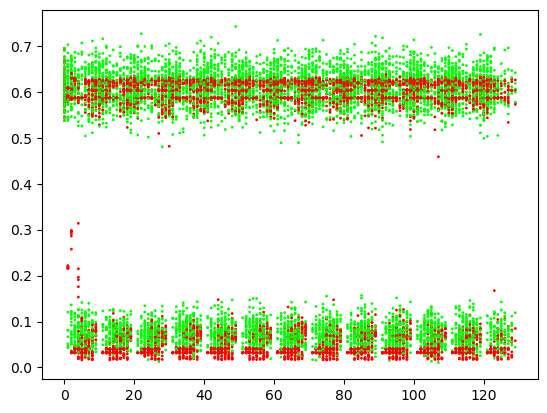

In [111]:
predictedsequenceSet = [] # this is without autoregression

for i in range(0, len(trainSequenceSet)):
    seq = standardizeMM(trainSequenceSet[i])
    seqWrapped = torch.stack([seq])
    predseqWrapped = rnn(seqWrapped).detach()
    predseq = predseqWrapped[0]
    predictedsequenceSet.append(predseq)
    stdpred = torch.std(predseq, dim=1)
    stdactual = torch.std(seq, dim=1)
    #print(ratio_sds.shape)
    plt.scatter(range(0, len(stdpred)), stdpred, c=np.tile(np.array([1, 0, 0]), (len(stdpred), 1)), s=1)
    plt.scatter(range(0, len(stdactual)), stdactual, c=np.tile(np.array([0, 1, 0]), (len(stdactual), 1)), s=1)
    #print("Actual: \t", torch.mean(seq[lower:upper]).item(), "\t",torch.std(seq[lower:upper]).item())
    #print("Predicted:\t", torch.mean(predseq[lower:upper]).item(), "\t",torch.std(predseq[lower:upper]).item())
    #print()
plt.savefig(f"{datapath}/trial_{trial_number}/prediction_variation.png")
plt.show()

In [112]:
# save the model
torch.save({
            'optimizer_state_dict': optimizerRNN.state_dict(),
            'model_state_dict': rnn.state_dict(),
            'loss': rnn_losses,
            }, 
            datapath+"/"+"trial_"+str(trial_number)+"/rnn_model.pt" )
# save the model information
with open(datapath+"/"+"trial_"+str(trial_number)+"/rnn_model_info.txt", "w") as f:
    f.write(str(rnn)+"\n")
    f.write(str(optimizerRNN)+"\n")
    f.write("Batch size: "+str(dataloader_batch_size)+"\n")

In [113]:
imageBounds = 2

for i in range(0, len(trainfilelist)):
    predseq = predictedsequenceSet[i]
    actseq = standardizeMM(trainSequenceSet[i])
    #saveSpec(predseq.numpy(), datapath+"sample_"+str(i)+"_rnn_trial"+str(trial_number)+".png", 2)
    #saveSpec(actseq.numpy(), datapath+"sample_"+str(i)+"_act.png", 2)
    matplotlib.image.imsave(datapath+"/"+"trial_"+str(trial_number)+"/sample_"+str(i)+".png",\
                            makeSpecSidebySide(actseq.numpy(), predseq.numpy(), imageBounds) )
    with open(datapath+"/"+"trial_"+str(trial_number)+"/sample_"+str(i)+".valuerange", "w") as f:
        f.write(f"actual sequence range: [{torch.min(actseq).item()}, {torch.max(actseq).item()}]\n")
        f.write(f"predicted sequence range: [{torch.min(predseq).item()}, {torch.max(predseq).item()}]\n")
        f.write(f"Image bounds: {imageBounds}\n")
    #torch.save(predseq, datapath+"/"+"trial_"+str(trial_number)+"/sample_"+str(i)+"_rnn_trial"+str(trial_number)+".pt")

Real Image max:  127
Real Image min:  0
Model Image max:  111
Model Image min:  0
Real Image max:  127
Real Image min:  0
Model Image max:  111
Model Image min:  0
Real Image max:  125
Real Image min:  0
Model Image max:  113
Model Image min:  0
Real Image max:  119
Real Image min:  0
Model Image max:  115
Model Image min:  0
Real Image max:  123
Real Image min:  0
Model Image max:  110
Model Image min:  0
Real Image max:  121
Real Image min:  0
Model Image max:  112
Model Image min:  0
Real Image max:  125
Real Image min:  0
Model Image max:  160
Model Image min:  0
Real Image max:  120
Real Image min:  0
Model Image max:  170
Model Image min:  0
Real Image max:  120
Real Image min:  0
Model Image max:  111
Model Image min:  0
Real Image max:  127
Real Image min:  0
Model Image max:  113
Model Image min:  0
Real Image max:  123
Real Image min:  0
Model Image max:  113
Model Image min:  0
Real Image max:  125
Real Image min:  0
Model Image max:  122
Model Image min:  0
Real Image max: 

## See how well RNN can predict immediate next element in test set

In [114]:
testSequenceSet = []

TEST_LENGTH = 0

for fname in testfilelist:
    sequence = torch.load(datapath+fname).to(torch.float32)
    print("type:",sequence.dtype)
    testSequenceSet.append(sequence)

    TEST_LENGTH += sequence.shape[0]

print("TEST LENGTH:", TEST_LENGTH)

type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32
type: torch.float32


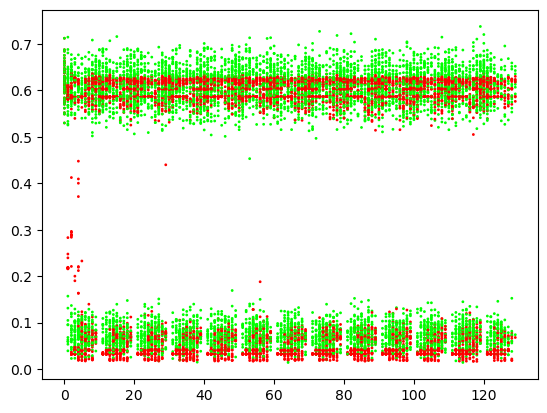

In [115]:
predictedtestsequenceSet = [] # this is without autoregression

for i in range(0, len(testSequenceSet)):
    seq = standardizeMM(testSequenceSet[i])
    seqWrapped = torch.stack([seq])
    predseqWrapped = rnn(seqWrapped).detach()
    predseq = predseqWrapped[0]
    predictedtestsequenceSet.append(predseq)
    stdpred = torch.std(predseq, dim=1)
    stdactual = torch.std(seq, dim=1)
    #print(ratio_sds.shape)
    plt.scatter(range(0, len(stdpred)), stdpred, c=np.tile(np.array([1, 0, 0]), (len(stdpred), 1)), s=1)
    plt.scatter(range(0, len(stdactual)), stdactual, c=np.tile(np.array([0, 1, 0]), (len(stdactual), 1)), s=1)
    #print("Actual: \t", torch.mean(seq[lower:upper]).item(), "\t",torch.std(seq[lower:upper]).item())
    #print("Predicted:\t", torch.mean(predseq[lower:upper]).item(), "\t",torch.std(predseq[lower:upper]).item())
    #print()
plt.savefig(f"{datapath}/trial_{trial_number}/prediction_variation_test.png")
plt.show()

In [ ]:
imageBounds = 2

if not os.path.isdir(f"{datapath}/trial_{trial_number}/test"):
    os.mkdir(f"{datapath}/trial_{trial_number}/test")

for i in range(0, len(testfilelist)):
    predseq = predictedtestsequenceSet[i]
    actseq = standardizeMM(testSequenceSet[i])
    #saveSpec(predseq.numpy(), datapath+"sample_"+str(i)+"_rnn_trial"+str(trial_number)+".png", 2)
    #saveSpec(actseq.numpy(), datapath+"sample_"+str(i)+"_act.png", 2)
    matplotlib.image.imsave(datapath+"/"+"trial_"+str(trial_number)+"/test/sample_"+str(i)+".png",\
                            makeSpecSidebySide(actseq.numpy(), predseq.numpy(), imageBounds) )
    with open(datapath+"/"+"trial_"+str(trial_number)+"/test/sample_"+str(i)+".valuerange", "w") as f:
        f.write(f"actual sequence range: [{torch.min(actseq).item()}, {torch.max(actseq).item()}]\n")
        f.write(f"predicted sequence range: [{torch.min(predseq).item()}, {torch.max(predseq).item()}]\n")
        f.write(f"Image bounds: {imageBounds}\n")
    #torch.save(predseq, datapath+"/"+"trial_"+str(trial_number)+"/sample_"+str(i)+"_rnn_trial"+str(trial_number)+".pt")

Real Image max:  130
Real Image min:  0
Model Image max:  116
Model Image min:  0
Real Image max:  122
Real Image min:  0
Model Image max:  122
Model Image min:  0
Real Image max:  126
Real Image min:  0
Model Image max:  111
Model Image min:  0
Real Image max:  122
Real Image min:  0
Model Image max:  113
Model Image min:  0
Real Image max:  128
Real Image min:  0
Model Image max:  113
Model Image min:  0
Real Image max:  122
Real Image min:  0
Model Image max:  109
Model Image min:  0
Real Image max:  123
Real Image min:  0
Model Image max:  119
Model Image min:  0
Real Image max:  124
Real Image min:  0
Model Image max:  170
Model Image min:  0
Real Image max:  121
Real Image min:  0
Model Image max:  168
Model Image min:  0
Real Image max:  127
Real Image min:  0
Model Image max:  113
Model Image min:  0
Real Image max:  125
Real Image min:  0
Model Image max:  115
Model Image min:  0
Real Image max:  123
Real Image min:  0
Model Image max:  110
Model Image min:  0
Real Image max: 

## See how well RNN can autoregress / generate next element on artificially generated elements

In [143]:
noise_std = 1.1

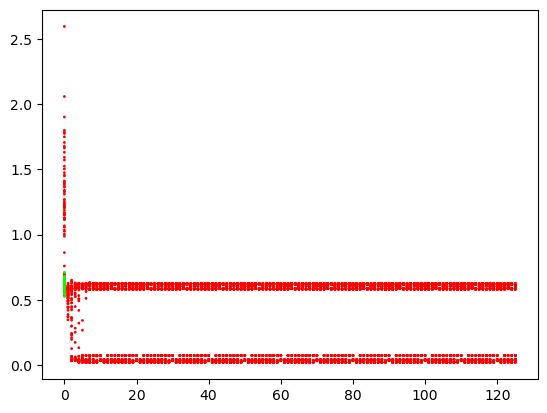

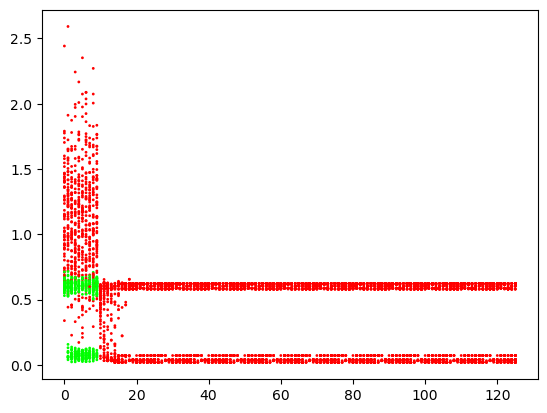

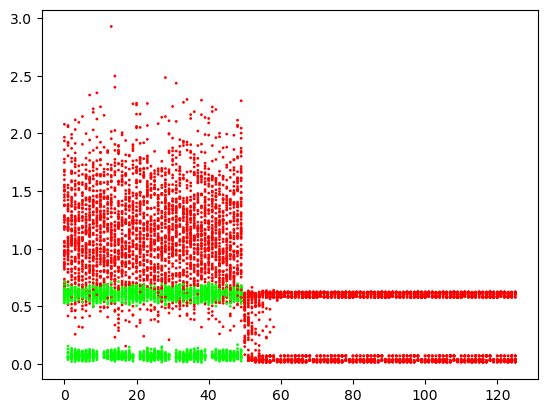

In [144]:
autoregsequenceSet = {1: [], 10: [], 50: []}

if not os.path.isdir(f"{datapath}/trial_{trial_number}/autoreg_{noise_std}"):
    os.mkdir(f"{datapath}/trial_{trial_number}/autoreg_{noise_std}")

for start_length in autoregsequenceSet:
    for i in range(0, len(testSequenceSet)):
        seq = standardizeMM(testSequenceSet[i][:start_length])
        seqWrapped = torch.stack([seq])
        seqWrapped = seqWrapped + torch.normal(mean=0, std=noise_std, size=seqWrapped.shape)
        predseqWrapped = rnn.forwardAutoreg(seqWrapped, 126).detach()
        predseq = predseqWrapped[0]
        autoregsequenceSet[start_length].append(predseq)
        stdpred = torch.std(predseq, dim=1)
        stdactual = torch.std(seq, dim=1)
        #print(ratio_sds.shape)
        plt.scatter(range(0, len(stdpred)), stdpred, c=np.tile(np.array([1, 0, 0]), (len(stdpred), 1)), s=1)
        plt.scatter(range(0, len(stdactual)), stdactual, c=np.tile(np.array([0, 1, 0]), (len(stdactual), 1)), s=1)
        #print("Actual: \t", torch.mean(seq[lower:upper]).item(), "\t",torch.std(seq[lower:upper]).item())
        #print("Predicted:\t", torch.mean(predseq[lower:upper]).item(), "\t",torch.std(predseq[lower:upper]).item())
        #print()
    plt.savefig(f"{datapath}/trial_{trial_number}/autoreg_{noise_std}/prediction_variation_autoreg_{start_length}.png")
    plt.show()

In [145]:
imageBounds = 2

for start_length in autoregsequenceSet:
    for i in range(0, len(testfilelist)):
        predseq = autoregsequenceSet[start_length][i]
        actseq = standardizeMM(testSequenceSet[i])
        #saveSpec(predseq.numpy(), datapath+"sample_"+str(i)+"_rnn_trial"+str(trial_number)+".png", 2)
        #saveSpec(actseq.numpy(), datapath+"sample_"+str(i)+"_act.png", 2)
        matplotlib.image.imsave(f"{datapath}/trial_{trial_number}/autoreg_{noise_std}/sample_{i}_st{start_length}.png",\
                                makeSpecSidebySide(actseq.numpy(), predseq.numpy(), imageBounds) )
        with open(f"{datapath}/trial_{trial_number}/autoreg_{noise_std}/sample_{i}_st{start_length}.valuerange", "w") as f:
            f.write(f"actual sequence range: [{torch.min(actseq).item()}, {torch.max(actseq).item()}]\n")
            f.write(f"predicted sequence range: [{torch.min(predseq).item()}, {torch.max(predseq).item()}]\n")
            f.write(f"Image bounds: {imageBounds}\n")
        #torch.save(predseq, datapath+"/"+"trial_"+str(trial_number)+"/sample_"+str(i)+"_rnn_trial"+str(trial_number)+".pt")

Real Image max:  130
Real Image min:  0
Model Image max:  255
Model Image min:  0
Real Image max:  122
Real Image min:  0
Model Image max:  255
Model Image min:  0
Real Image max:  126
Real Image min:  0
Model Image max:  255
Model Image min:  0
Real Image max:  122
Real Image min:  0
Model Image max:  181
Model Image min:  0
Real Image max:  128
Real Image min:  0
Model Image max:  255
Model Image min:  0
Real Image max:  122
Real Image min:  0
Model Image max:  255
Model Image min:  0
Real Image max:  123
Real Image min:  0
Model Image max:  255
Model Image min:  0
Real Image max:  124
Real Image min:  0
Model Image max:  255
Model Image min:  0
Real Image max:  121
Real Image min:  0
Model Image max:  255
Model Image min:  0
Real Image max:  127
Real Image min:  0
Model Image max:  255
Model Image min:  0
Real Image max:  125
Real Image min:  0
Model Image max:  255
Model Image min:  0
Real Image max:  123
Real Image min:  0
Model Image max:  221
Model Image min:  0
Real Image max: 

# Analyze LayerNorm Layers to determine why outputs seem to be muted

In [ ]:
idx = 3
print(rnn.main[idx])
plt.hist(torch.flatten(rnn.main[idx].weight).detach().numpy(), bins=50)

In [ ]:
sequencePred = rnn(newData[1]).detach().numpy()
print(sequencePred.shape)
for i in range(0, 5):
    print(sequencePred.shape)
    plt.plot([t[0] for t in sequencePred[i]][:newData[0][i]], [t[1] for t in sequencePred[i]][:newData[0][i]])